# Aerial Object Classification (Bird vs Drone)
End-to-end notebook

## 1. Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

In [8]:
import sys
print(sys.executable)

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\python.exe


In [9]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## 2. Paths

In [10]:
train_path = "data/train"
val_path = "data/val"
test_path = "data/test"

## 3. Data Generators

In [ ]:
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=15,
zoom_range=0.2,
horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
train_path,
target_size=(224, 224),
batch_size=32,
class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
val_path,
target_size=(224, 224),
batch_size=32,
class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


## 4. Sample Images

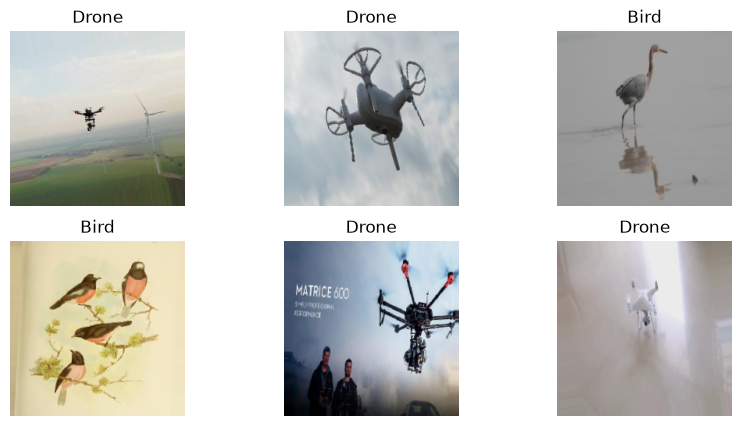

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
 plt.subplot(2,3,i+1)
 plt.imshow(images[i])
 plt.title("Bird" if labels[i]==0 else "Drone")
 plt.axis("off")
plt.show()

## 5. Model

In [13]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = Sequential([
base_model,
GlobalAveragePooling2D(),
Dense(128, activation='relu'),
Dropout(0.4),
Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Callbacks

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

## 7. Training

In [15]:
history = model.fit(
train_data,
validation_data=val_data,
epochs=10,
callbacks=[early_stop, checkpoint]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.8648 - loss: 0.2873

84/84 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9267 - loss: 0.1754 - val_accuracy: 0.9683 - val_loss: 0.0831
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 67s 799ms/step - accuracy: 0.9737 - loss: 0.0761 - val_accuracy: 0.9638 - val_loss: 0.1157
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 60s 711ms/step - accuracy: 0.9820 - loss: 0.0584 - val_accuracy: 0.9706 - val_loss: 0.0839
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9835 - loss: 0.0513

84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 706ms/step - accuracy: 0.9835 - loss: 0.0493 - val_accuracy: 0.9729 - val_loss: 0.0682
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 697ms/step - accuracy: 0.9820 - loss: 0.0422 - val_accuracy: 0.9661 - val_loss: 0.0693
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 58s 695ms/step - accuracy: 0.9880 - loss: 0.0315 - val_accuracy: 0.9593 - val_loss: 0.1284
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9902 - loss: 0.0290

84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 705ms/step - accuracy: 0.9891 - loss: 0.0331 - val_accuracy: 0.9796 - val_loss: 0.0565
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 705ms/step - accuracy: 0.9940 - loss: 0.0228 - val_accuracy: 0.9751 - val_loss: 0.0826
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 703ms/step - accuracy: 0.9895 - loss: 0.0294 - val_accuracy: 0.9683 - val_loss: 0.0750
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 700ms/step - accuracy: 0.9947 - loss: 0.0153 - val_accuracy: 0.9729 - val_loss: 0.0755


## 8. Plots

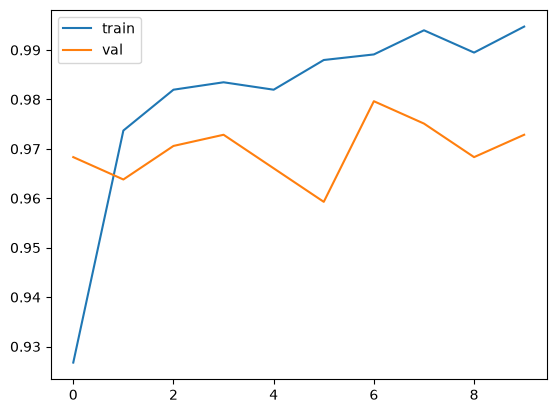

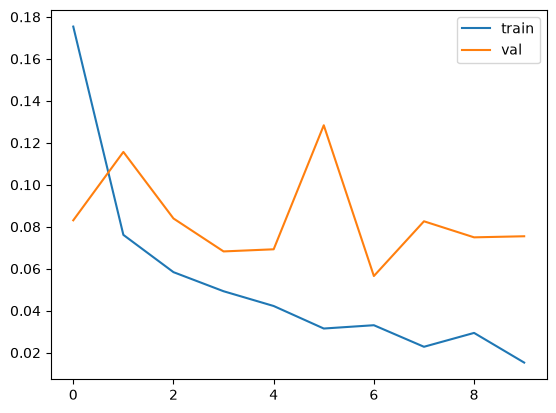

In [16]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

## 9. Test Evaluation

In [17]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
test_path,
target_size=(224,224),
batch_size=32,
class_mode='binary',
shuffle=False
)

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 589ms/step - accuracy: 0.9674 - loss: 0.0923
Test Accuracy: 0.9674418568611145


## 10. Predictions

In [18]:
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 623ms/step


## 11. Report

In [19]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       121
           1       0.97      0.96      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



## 12. Confusion Matrix

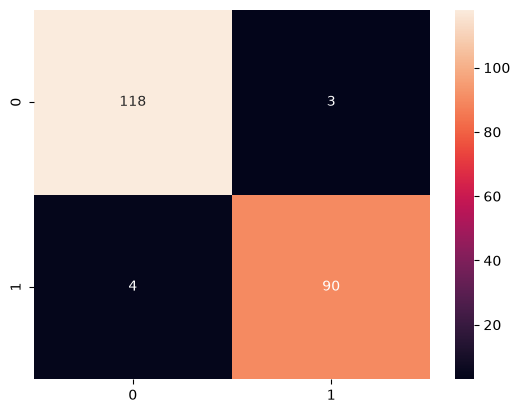

In [20]:
cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## 13. Save Model

In [21]:
model.save("final_model.h5")